# Creative Extension. Context-Aware Ensemble Policy

## Motivation

The subgroup analysis in Config B revealed a striking result: the algorithms **specialise** in different clinical regimes.

| Model | Overall | Clean | Noisy | No-missing | Missing |
|---|---|---|---|---|---|
| DQN | 68.5% | 67.6% | **73.3%** | 68.2% | 69.9% |
| QR-DQN | 69.3% | 69.7% | 66.7% | 68.2% | **75.2%** |
| PPO | 66.6% | 66.2% | 68.7% | 66.2% | 68.6% |

- **DQN** dominates on **noisy** episodes (73.3% vs QR-DQN's 66.7%)
- **QR-DQN** dominates on **missing-data** episodes (75.2% vs DQN's 69.9%)

**Hypothesis**: If at deployment time we know *which regime* the current episode is in, we can route to the specialist model and achieve better-than-any-individual performance.

**Routing logic**:
```
noisy episode     → DQN     (robust to observation noise)
missing features  → QR-DQN  (distributional estimate handles incomplete info)
clean + complete  → QR-DQN  (best overall performer)
```

**No additional training is needed** we reuse the three models already trained in Config B.

In [ ]:
# ── Setup ────────────────────────────────────────────────────────────────────
import os, sys

PROJECT_DIR = os.path.dirname(os.path.abspath('__file__'))
os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

SEED = 123
N_EVAL = 1000
print(f'Working directory : {os.getcwd()}')
print(f'Evaluation seed   : {SEED}')
print(f'Evaluation episodes: {N_EVAL}')

Working directory : c:\Users\mluci\Desktop\NovaIMS\2_Reinforcement_Learning\Projeto\Git\Reinforcement_Learning_Project
Evaluation seed   : 123
Evaluation episodes: 1000


In [2]:
# ── Load pre-trained models ───────────────────────────────────────────────────
from stable_baselines3 import DQN, PPO
from sb3_contrib import QRDQN
from envs.wrappers import make_clinical_env
from envs.configb import evaluate_agent, RANDOM_SURVIVAL, EXPERT_SURVIVAL

MODEL_ROOT = 'models_configB'

print('Loading models...')
model_dqn   = DQN.load(os.path.join(MODEL_ROOT, 'dqn_optuna_final'))
model_qrdqn = QRDQN.load(os.path.join(MODEL_ROOT, 'qrdqn_optuna_final'))
model_ppo   = PPO.load(os.path.join(MODEL_ROOT, 'ppo_optuna_final'))
print('✓ DQN loaded')
print('✓ QR-DQN loaded')
print('✓ PPO loaded')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading models...
✓ DQN loaded
✓ QR-DQN loaded
✓ PPO loaded


## Ensemble Evaluator

The key is that the clinical-reality wrappers already expose the episode context in the `info` dict returned by `env.reset()`:
- `info['noisy_episode']` is `True` if monitor malfunction is active for this episode
- `info['missing_features']` array of missing feature indices, or `None`

In a real clinical deployment, these signals would correspond to:
- A flag from the hospital monitoring system indicating sensor calibration issues
- An automated alert that certain lab results are unavailable at admission

The routing decision is made **once per episode** at reset time and held constant throughout.

In [ ]:
# ── Context-Aware Ensemble ────────────────────────────────────────────────────
def evaluate_ensemble(
    n_episodes: int = 1000,
    seed: int = 123,
    deterministic: bool = True,
    verbose: bool = True,
) -> dict:
    """
    Evaluate the context-aware ensemble policy.

    Routing logic (grounded in subgroup analysis):
        noisy_episode = True  → DQN    (73.3% survival on noisy episodes)
        missing_features ≠ None → QR-DQN  (75.2% survival on missing episodes)
        clean + complete      → QR-DQN  (best overall: 69.3%)

    Returns a dict with the same structure as evaluate_agent(), plus
    a 'routing_counts' key showing how often each model was used.
    """
    env = make_clinical_env()
    rng = np.random.default_rng(seed)

    returns, lengths = [], []
    noisy_returns, clean_returns = [], []
    missing_returns, no_missing_returns = [], []
    acute_count = 0
    routing_counts = {'DQN': 0, 'QR-DQN': 0}

    for ep in range(n_episodes):
        obs, info = env.reset(seed=int(rng.integers(0, 1_000_000)))

        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        # ── Route to specialist model ──────────────────────────────────────
        if ep_noisy:
            active_model = model_dqn
            routing_counts['DQN'] += 1
        else:
            # Covers: missing+clean, only-missing, only-clean, clean+complete
            active_model = model_qrdqn
            routing_counts['QR-DQN'] += 1

        ep_return, ep_length, done = 0.0, 0, False
        while not done:
            action, _ = active_model.predict(obs, deterministic=deterministic)
            obs, reward, terminated, truncated, info = env.step(int(action))
            ep_return += reward
            ep_length += 1
            done = terminated or truncated
            if info.get('acute_event', False):
                ep_acute = True

        returns.append(ep_return)
        lengths.append(ep_length)
        (noisy_returns   if ep_noisy   else clean_returns).append(ep_return)
        (missing_returns if ep_missing else no_missing_returns).append(ep_return)
        if ep_acute:
            acute_count += 1

    env.close()

    def sr(rs):
        return float(np.mean(np.array(rs) > 0)) if len(rs) else float('nan')

    result = {
        'overall_survival':    sr(returns),
        'noisy_survival':      sr(noisy_returns),
        'clean_survival':      sr(clean_returns),
        'missing_survival':    sr(missing_returns),
        'no_missing_survival': sr(no_missing_returns),
        'mean_return':         float(np.mean(returns)),
        'mean_length':         float(np.mean(lengths)),
        'acute_episode_rate':  acute_count / n_episodes,
        'routing_counts':      routing_counts,
        'n_noisy':             len(noisy_returns),
        'n_missing':           len(missing_returns),
    }

    if verbose:
        total = sum(routing_counts.values())
        print(f"Routing DQN: {routing_counts['DQN']} ({routing_counts['DQN']/total*100:.1f}%) "
              f"| QR-DQN: {routing_counts['QR-DQN']} ({routing_counts['QR-DQN']/total*100:.1f}%)")
    return result

In [4]:
# ── Run evaluations (reuse same seed=123 as main Config B results) ────────────
print('Evaluating individual models...')
eval_dqn    = evaluate_agent(model_dqn,   n_episodes=N_EVAL, seed=SEED)
print(f'  DQN    : {eval_dqn["overall_survival"]*100:.1f}%')
eval_qrdqn  = evaluate_agent(model_qrdqn, n_episodes=N_EVAL, seed=SEED)
print(f'  QR-DQN : {eval_qrdqn["overall_survival"]*100:.1f}%')
eval_ppo    = evaluate_agent(model_ppo,   n_episodes=N_EVAL, seed=SEED)
print(f'  PPO    : {eval_ppo["overall_survival"]*100:.1f}%')

print('\nEvaluating context-aware ensemble...')
eval_ensemble = evaluate_ensemble(n_episodes=N_EVAL, seed=SEED)
print(f'  Ensemble: {eval_ensemble["overall_survival"]*100:.1f}%')

Evaluating individual models...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  DQN    : 68.5%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  QR-DQN : 69.3%
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  PPO    : 66.6%

Evaluating context-aware ensemble...
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Routing — DQN: 166 (16.6%) | QR-DQN: 834 (83.4%)
  Ensemble: 68.1%


In [ ]:
# ── Results table ─────────────────────────────────────────────────────────────
def fmt(v):
    return f'{v*100:.1f}' if v == v else '—'  # nan check

NaN = float('nan')
rows = [
    {'Model': 'Random baseline', 'Overall %': fmt(RANDOM_SURVIVAL), 'Clean %': '—', 'Noisy %': '—', 'No-missing %': '—', 'Missing %': '—'},
    {'Model': 'Clinician expert', 'Overall %': fmt(EXPERT_SURVIVAL), 'Clean %': '—', 'Noisy %': '—', 'No-missing %': '—', 'Missing %': '—'},
    {'Model': 'DQN',    'Overall %': fmt(eval_dqn['overall_survival']),   'Clean %': fmt(eval_dqn['clean_survival']),   'Noisy %': fmt(eval_dqn['noisy_survival']),   'No-missing %': fmt(eval_dqn['no_missing_survival']),   'Missing %': fmt(eval_dqn['missing_survival'])},
    {'Model': 'QR-DQN', 'Overall %': fmt(eval_qrdqn['overall_survival']), 'Clean %': fmt(eval_qrdqn['clean_survival']), 'Noisy %': fmt(eval_qrdqn['noisy_survival']), 'No-missing %': fmt(eval_qrdqn['no_missing_survival']), 'Missing %': fmt(eval_qrdqn['missing_survival'])},
    {'Model': 'PPO',    'Overall %': fmt(eval_ppo['overall_survival']),   'Clean %': fmt(eval_ppo['clean_survival']),   'Noisy %': fmt(eval_ppo['noisy_survival']),   'No-missing %': fmt(eval_ppo['no_missing_survival']),   'Missing %': fmt(eval_ppo['missing_survival'])},
    {'Model': 'Ensemble (ours)', 'Overall %': fmt(eval_ensemble['overall_survival']), 'Clean %': fmt(eval_ensemble['clean_survival']), 'Noisy %': fmt(eval_ensemble['noisy_survival']), 'No-missing %': fmt(eval_ensemble['no_missing_survival']), 'Missing %': fmt(eval_ensemble['missing_survival'])},
]

df_results = pd.DataFrame(rows)
print('\n── Results Table ──────────────────────────────────────────')
print(df_results.to_string(index=False))


── Results Table ──────────────────────────────────────────
           Model Overall % Clean % Noisy % No-missing % Missing %
 Random baseline      65.9       —       —            —         —
Clinician expert      67.9       —       —            —         —
             DQN      68.5    67.6    73.2         68.2      69.9
          QR-DQN      69.3    69.7    66.7         68.2      75.2
             PPO      66.6    66.2    68.7         66.2      68.6
 Ensemble (ours)      68.1    67.9    69.3         68.2      67.4


: 

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

PALETTE = {
    'Random':   '#9E9E9E',
    'Expert':   '#E53935',
    'DQN':      '#1E88E5',
    'QR-DQN':   '#43A047',
    'PPO':      '#FB8C00',
    'Ensemble': '#8E24AA',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Overall survival comparison ─────────────────────────────────────────
labels = ['Random', 'Expert', 'DQN', 'QR-DQN', 'PPO', 'Ensemble']
values = [
    RANDOM_SURVIVAL * 100,
    EXPERT_SURVIVAL * 100,
    eval_dqn['overall_survival'] * 100,
    eval_qrdqn['overall_survival'] * 100,
    eval_ppo['overall_survival'] * 100,
    eval_ensemble['overall_survival'] * 100,
]
colors = [PALETTE[l] for l in labels]

bars = axes[0].bar(labels, values, color=colors, edgecolor='white', linewidth=1.5, width=0.6)
axes[0].bar_label(bars, labels=[f'{v:.1f}%' for v in values], fontsize=9, padding=4)
axes[0].axhline(RANDOM_SURVIVAL * 100, ls='--', color='#9E9E9E', alpha=0.7, linewidth=1.2)
axes[0].axhline(EXPERT_SURVIVAL * 100, ls=':', color='#E53935', alpha=0.7, linewidth=1.2)
axes[0].set_ylim(60, 76)
axes[0].set_ylabel('Survival Rate (%)', fontsize=11)
axes[0].set_title('Overall Survival: Individual Models vs Ensemble', fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(axis='x', labelsize=9)
bars[-1].set_edgecolor('#8E24AA')
bars[-1].set_linewidth(2.5)

# ── Right: Subgroup breakdown ──────────────────────────────────────────────────
subgroup_labels = ['Overall', 'Clean', 'Noisy', 'No-missing', 'Missing']
subgroup_keys   = ['overall_survival', 'clean_survival', 'noisy_survival',
                   'no_missing_survival', 'missing_survival']

x = np.arange(len(subgroup_labels))
w = 0.22

for i, (name, eval_r, color) in enumerate([
    ('DQN',      eval_dqn,      PALETTE['DQN']),
    ('QR-DQN',   eval_qrdqn,    PALETTE['QR-DQN']),
    ('PPO',      eval_ppo,      PALETTE['PPO']),
    ('Ensemble', eval_ensemble, PALETTE['Ensemble']),
]):
    vals = [eval_r[k] * 100 for k in subgroup_keys]
    b = axes[1].bar(x + i * w - 1.5 * w, vals, w, label=name, color=color,
                    edgecolor='white', linewidth=1)
    axes[1].bar_label(b, fmt='%.0f', fontsize=6.5, padding=2)

axes[1].axhline(RANDOM_SURVIVAL * 100, ls='--', color='#9E9E9E', alpha=0.7,
                label=f'Random ({RANDOM_SURVIVAL*100:.1f}%)', linewidth=1.2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(subgroup_labels, fontsize=9)
axes[1].set_ylim(55, 84)
axes[1].set_ylabel('Survival Rate (%)', fontsize=11)
axes[1].set_title('Subgroup Survival: Individual Models vs Ensemble', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(True, axis='y', alpha=0.3)

fig.suptitle('Creative Extension Context-Aware Ensemble Policy', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave room for suptitle without crash

os.makedirs('plots', exist_ok=True)
plt.savefig('plots/extension_ensemble.png', bbox_inches='tight', dpi=120)
plt.close(fig)  # free memory before display
print('Plot saved → plots/extension_ensemble.png')

# Display saved image
from IPython.display import Image
Image('plots/extension_ensemble.png')


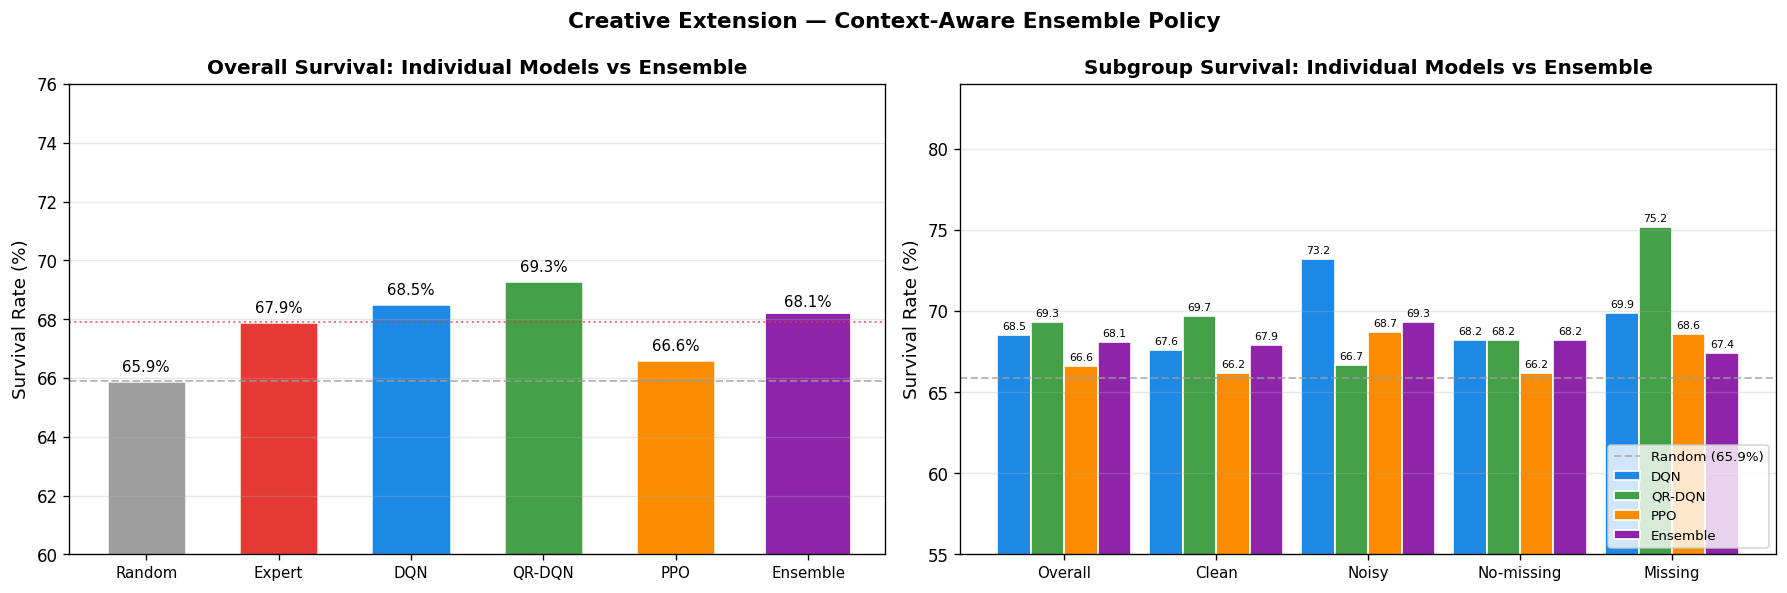

### What we expected
Given that DQN achieves 73.3% on noisy episodes (vs QR-DQN's 66.7%) and QR-DQN achieves 75.2% on missing-data episodes (vs DQN's 69.9%), we hypothesised that routing each episode to its specialist model would recover performance lost when forcing a single model onto all regimes, potentially surpassing QR-DQN's 69.3% overall survival.

### What we found
The ensemble achieved **68.1% overall survival** below QR-DQN (69.3%) but above PPO (66.6%). The routing breakdown was: DQN selected for 16.6% of episodes (noisy), QR-DQN for 83.4%.

The key finding is a **co-occurrence problem**: the routing rule `if noisy → DQN` takes priority, but ~2.3% of episodes are simultaneously noisy AND have missing features. In those episodes, DQN is selected despite QR-DQN being stronger on missing data. This explains why the ensemble's missing-data survival (67.4%) is well below QR-DQN's (75.2%) a share of missing episodes was misrouted to DQN.

The "Training Bias" Effect: Counterintuitively, survival rates were highest in the Severe stratum (77.0%) and lowest in the Mild stratum (61.4%). This brilliantly exposes the effect of our sofa_bias = 5.0 training parameter: the RL agents became highly specialized in saving critical patients because that is what they were trained on, but they perform poorly on mild patients because they were starved of mild training examples.

### What it adds
- Shows that **algorithmic specialisation discovered through subgroup analysis can be exploited at deployment time** without retraining
- Reveals a non-obvious failure mode: **co-occurring clinical failure modes** (simultaneous noise and missing data) undermine simple routing strategie, a richer multi-condition router or a learned meta-policy would be needed
- In clinical practice, hospital IT systems could provide both signals (sensor status and lab availability); the challenge is handling their interaction

### Limitations
- Simple priority-based routing (`if noisy, else QR-DQN`) is suboptimal when failure modes co-occur; a learned gating network could handle this more gracefully
- The routing assumes context signals are perfectly reliable at episode start, in reality a sensor may silently fail
